In [18]:
import numpy as np
import pandas as pd

np.random.seed(23) 

mu_vec1 = np.array([0,0,0])
cov_mat1 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

df = pd.DataFrame(class1_sample,columns=['feature1','feature2','feature3'])
df['target'] = 1

mu_vec2 = np.array([1,1,1])
cov_mat2 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

df1 = pd.DataFrame(class2_sample,columns=['feature1','feature2','feature3'])

df1['target'] = 0

df = pd.concat([df, df1], ignore_index=True)

df = df.sample(40)

In [3]:
df.head()

,feature1,feature2,feature3,target
2,-0.367548,-1.137460,-1.322148,1
34,0.177061,-0.598109,1.226512,0
14,0.420623,0.411620,-0.071324,1
11,1.968435,-0.547788,-0.679418,1
12,-2.506230,0.146960,0.606195,1


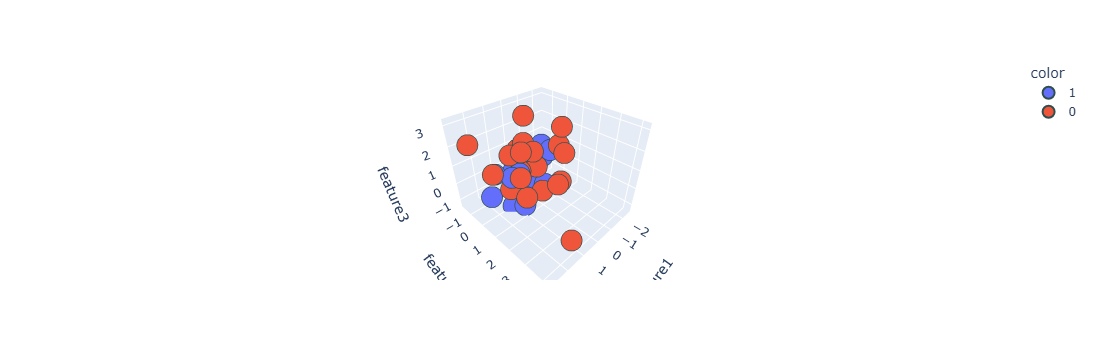

In [4]:
import plotly.express as px
#y_train_trf = y_train.astype(str)
fig = px.scatter_3d(df, x=df['feature1'], y=df['feature2'], z=df['feature3'],
              color=df['target'].astype('str'))
fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))

fig.show()

In [9]:
# Step 1 - Apply standard scaling or Mean centering
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df.iloc[:, 0:3] = scaler.fit_transform(df.iloc[:, 0:3])

In [10]:
# Step 2 - Find Coveriance Matrix
covariance_matrix = np.cov([df.iloc[:, 0], df.iloc[:, 1], df.iloc[:, 2]])
print("Covariance Matrix: \n", covariance_matrix)

Covariance Matrix: 
 [[1.02564103 0.20478114 0.080118  ]
 [0.20478114 1.02564103 0.19838882]
 [0.080118   0.19838882 1.02564103]]


In [11]:
# Step 3 - Finding eigen vector and eigen values
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

In [12]:
eigen_values

array([1.3536065 , 0.94557084, 0.77774573])

In [13]:
eigen_vectors

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442],
       [-0.52848211,  0.72025103,  0.44938304]])

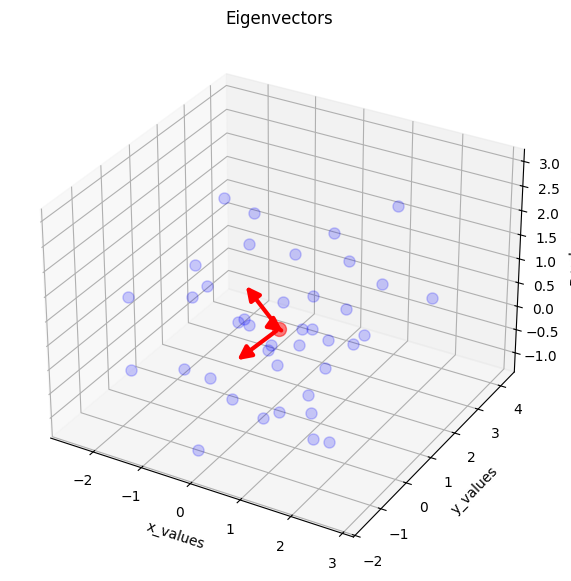

In [19]:
%matplotlib inline
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d import proj3d
from matplotlib.patches import FancyArrowPatch

# Naya aur complete Arrow3D class 3D projection ke sath
class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0, 0), (0, 0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def do_3d_projection(self):
        xs3d, ys3d, zs3d = self._verts3d
        # M matrix ko use karke 3D coordinates ko project karte hain
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        return np.min(zs)  # Depth sorting ke liye minimum z-value return karni hoti hai

    def draw(self, renderer):
        # Ab draw function simple ho jayega kyunki projection upar handle ho rahi hai
        super().draw(renderer)

# --- Aapka baaki plot ka code ---
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')

# Data points plot karna
ax.plot(df['feature1'], df['feature2'], df['feature3'], 'o', markersize=8, color='blue', alpha=0.2)

# Mean point plot karna (Red color mein)
ax.plot([df['feature1'].mean()], [df['feature2'].mean()], [df['feature3'].mean()], 'o', markersize=10, color='red', alpha=0.5)

# Eigenvectors ko Arrows ki shakal mein draw karna
for v in eigen_vectors.T:
    a = Arrow3D([df['feature1'].mean(), df['feature1'].mean() + v[0]], 
                [df['feature2'].mean(), df['feature2'].mean() + v[1]], 
                [df['feature3'].mean(), df['feature3'].mean() + v[2]], 
                mutation_scale=20, lw=3, arrowstyle="-|>", color="r")
    ax.add_artist(a)

ax.set_xlabel('x_values')
ax.set_ylabel('y_values')
ax.set_zlabel('z_values')

plt.title('Eigenvectors')
plt.show()

In [20]:
pc = eigen_vectors[0:2]
pc

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442]])

In [23]:
# Step 4 - Transform - shift orignal 3D data set (40,3) shift into 2D (40,2)
transformed_df = np.dot(df.iloc[:, 0:3], pc.T)
# 40,3 - (2,3) -> Transport then (3,2) ----> 40,3 - 3,2 = 40,2
new_df = pd.DataFrame(transformed_df, columns=['PC1', 'PC2'])

new_df['target'] = df['target'].values

new_df.head()

,PC1,PC2,target
0,0.354836,1.250883,1
1,0.905912,-1.035385,0
2,-0.546230,-0.226495,1
3,-1.005401,-0.772965,1
4,1.538160,1.185298,1


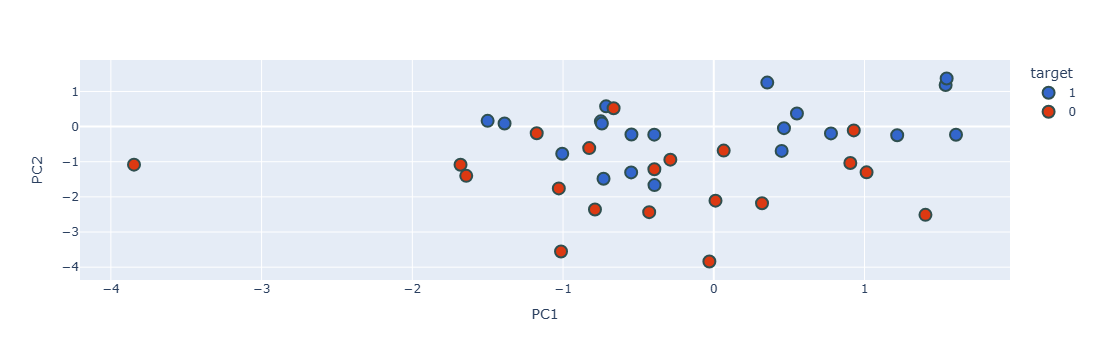

In [24]:
import plotly.express as px

# Target ko string mein convert kiya taaki discrete color map apply ho sake
new_df['target'] = new_df['target'].astype(str)

# FIX: data_frame pass kiya aur x, y, color mein sirf column ke naam diye
fig = px.scatter(
    data_frame=new_df,
    x='PC1',
    y='PC2',
    color='target',
    color_discrete_sequence=px.colors.qualitative.G10
)

# Traces ko update kiya styling ke liye
fig.update_traces(
    marker=dict(
        size=12,
        line=dict(width=2, color='DarkSlateGrey')
    ),
    selector=dict(mode='markers')
)

fig.show()